In [1]:
# GitHub Copilot
# compute oscillation period from peak timestamps
# Ku 200
times = [21.05, 23.45, 26.05, 28.15, 30.30, 32.35, 34.50, 36.55,
         39.05, 41.15, 43.25, 45.30, 47.40, 49.50]

#Ku = 175
# times = [50.25, 52.45, 54.50, 57.05, 59.20, 61.25, 63.35, 65.50, 68.00, 70.15, 72.25, 74.40, 76.45, 78.55]

In [ ]:
# !pip install pandas


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


number of peaks: 4
peak intervals [s]: [89. 89. 95.]
mean peak-to-peak period [s]: 91.0
Dominant frequency: 0.011904761904761906 Hz
Dominant period: 83.99999999999999 seconds


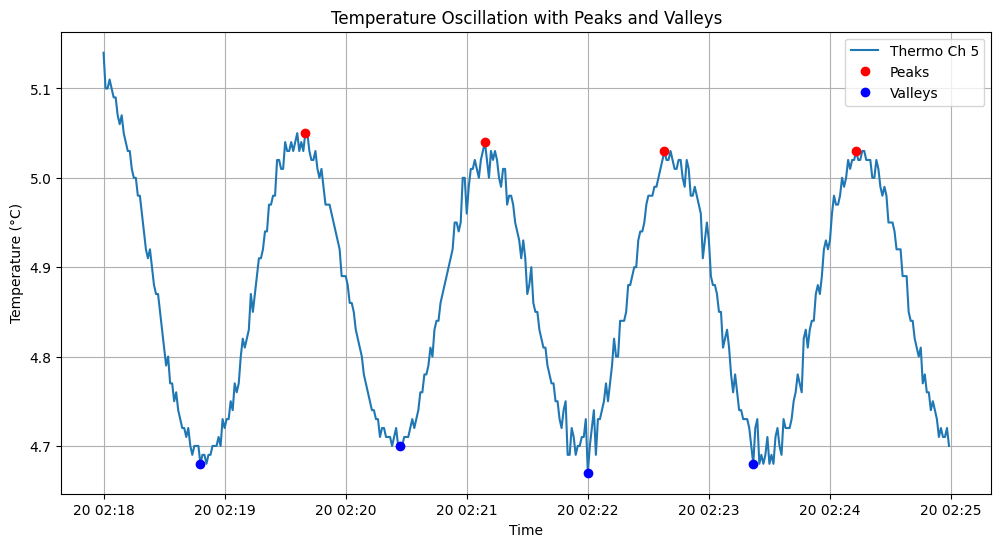

In [11]:
import pandas as pd
import numpy as np
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

path = r"C:\D\Study\4-1\CapStone\low-temperature-control\resource\temperature_data_2026-04-20T02_27_01.072Z.csv"
df = pd.read_csv(path)

# parse time to datetime
df['ts'] = pd.to_datetime(df['time'], utc=True)

# detect peaks and valleys in Thermo Ch 5
peaks, _ = find_peaks(df['Thermo Ch 5'], distance=70, prominence=0.05)
valleys, _ = find_peaks(-df['Thermo Ch 5'], distance=70, prominence=0.05)

peak_times = df.loc[peaks, 'ts']
valley_times = df.loc[valleys, 'ts']

# compute intervals between consecutive peaks
peak_intervals = peak_times.diff().dt.total_seconds().dropna().to_numpy()
mean_peak_period = peak_intervals.mean() if len(peak_intervals) > 0 else None

print("number of peaks:", len(peaks))
print("peak intervals [s]:", peak_intervals)
print("mean peak-to-peak period [s]:", mean_peak_period)

# FFT to find dominant period
temp = df['Thermo Ch 5'].values
time_seconds = (df['ts'] - df['ts'].iloc[0]).dt.total_seconds().values
fft = np.fft.fft(temp)
freqs = np.fft.fftfreq(len(temp), d=1)  # d=1 second
power = np.abs(fft)**2
# Find the peak in power spectrum (excluding DC)
idx = np.argmax(power[1:]) + 1
dominant_freq = freqs[idx]
dominant_period = 1 / dominant_freq if dominant_freq > 0 else None

print(f"Dominant frequency: {dominant_freq} Hz")
print(f"Dominant period: {dominant_period} seconds")

# Plot the temperature data with peaks and valleys marked
plt.figure(figsize=(12, 6))
plt.plot(df['ts'], df['Thermo Ch 5'], label='Thermo Ch 5')
plt.plot(peak_times, df.loc[peaks, 'Thermo Ch 5'], 'ro', label='Peaks')
plt.plot(valley_times, df.loc[valleys, 'Thermo Ch 5'], 'bo', label='Valleys')
plt.xlabel('Time')
plt.ylabel('Temperature (°C)')
plt.title('Temperature Oscillation with Peaks and Valleys')
plt.legend()
plt.grid(True)
plt.show()

In [3]:
# Convert times from min.seconds to total seconds
times_seconds = []
for t in times:
    minutes = int(t)
    seconds = (t - minutes) * 100
    total_seconds = minutes * 60 + seconds
    times_seconds.append(total_seconds)

deltas = [times_seconds[i] - times_seconds[i-1] for i in range(1, len(times_seconds))]
mean_period = sum(deltas) / len(deltas)

print("intervals:", deltas)
print("mean period:", mean_period)

intervals: [160.0, 140.0, 129.99999999999977, 135.00000000000023, 125.00000000000023, 134.99999999999977, 124.99999999999955, 130.0, 130.00000000000045, 130.0, 124.99999999999955, 130.00000000000045, 130.0]
mean period: 132.69230769230768


In [5]:
import numpy as np

mean_period = 132
# Ultimate gain and period
Ku = 180  # Replace with your ultimate gain value
Pu = mean_period  # Using the calculated mean period as ultimate period

# Ziegler-Nichols tuning for Classic PID controller
Kp = 0.6 * Ku
Ki = 1.2 * Ku / Pu
Kd = 0.075 * Ku * Pu

print("Ziegler-Nichols Tuning for Classic PID Controller:")
print(f"Kp (Proportional gain): {Kp}")
print(f"Ki (Integral gain): {Ki}")
print(f"Kd (Derivative gain): {Kd}")
print("----------------------------------------------------")

# Ziegler-Nichols tuning for No Overshoot PID controller
Kp = 0.2 * Ku
Ki = 0.4 * Ku / Pu
Kd = 6 / 90 * Ku * Pu

print("Ziegler-Nichols Tuning for No Overshoot PID Controller:")
print(f"Kp (Proportional gain): {Kp}")
print(f"Ki (Integral gain): {Ki}")
print(f"Kd (Derivative gain): {Kd}")

Ziegler-Nichols Tuning for Classic PID Controller:
Kp (Proportional gain): 108.0
Ki (Integral gain): 1.6363636363636365
Kd (Derivative gain): 1782.0
----------------------------------------------------
Ziegler-Nichols Tuning for No Overshoot PID Controller:
Kp (Proportional gain): 36.0
Ki (Integral gain): 0.5454545454545454
Kd (Derivative gain): 1584.0


Ku: 200
mean period: 132.69230769230768
Kp (Proportional gain): 40.0
Ki (Integral gain): 0.6028985507246377
Kd (Derivative gain): 1769.230769230769

-------------------------------------------------------------

# Ku: 180, mean period: 132

## Classic PID Controller:

Kp (Proportional gain): 108.0

Ki (Integral gain): 1.6363636363636365

Kd (Derivative gain): 1782.0

## No Overshoot PID Controller:

Kp (Proportional gain): 36.0

Ki (Integral gain): 0.5454545454545454

Kd (Derivative gain): 1584.0

---------------------------------------------------------------

Ku: 175
mean period: 131.53846153846155
Kp (Proportional gain): 35.0
Ki (Integral gain): 0.5321637426900584
Kd (Derivative gain): 1534.6153846153845